In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

print("All libraries imported successfully!")


All libraries imported successfully!


In [3]:
df = pd.read_csv("../data/Titanic-Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()


Dataset loaded successfully!
Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Display first 5 rows

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Display last 5 rows

df.tail()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [6]:
# Check number of rows and columns

print("Dataset Shape:", df.shape)


Dataset Shape: (891, 12)


In [7]:
# Display column names

print("Columns:")
print(df.columns.tolist())


Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [8]:
# Dataset information

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [9]:
# Statistical summary of numerical columns

df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
# Statistical summary including categorical columns

df.describe(include="all")


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [11]:
# Count missing values in each column

missing_values = df.isnull().sum()

print(missing_values)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [12]:
# Calculate missing value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage.sort_values(ascending=False))


Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64


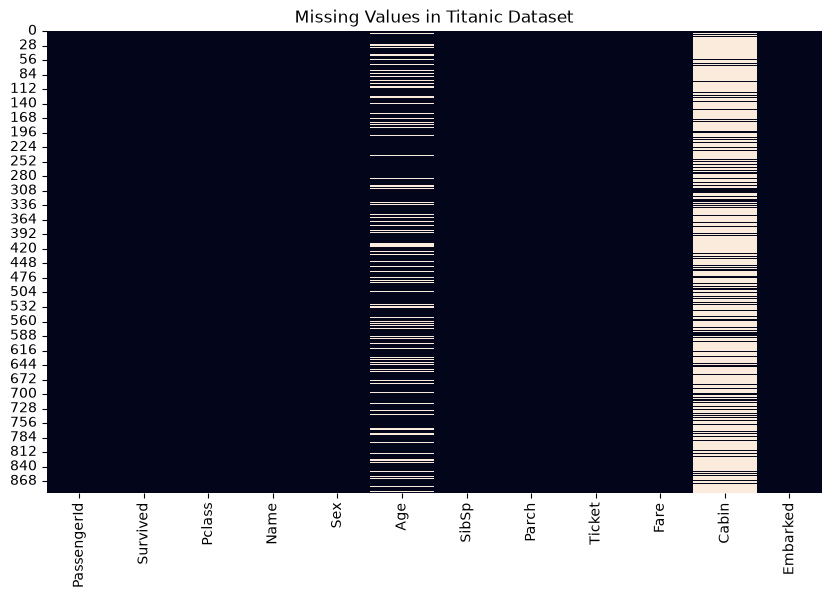

In [13]:
plt.figure(figsize=(10, 6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values in Titanic Dataset")
plt.show()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.drop_duplicates(inplace=True)


In [16]:
# Check missing values in Age

print("Missing Age values:", df["Age"].isnull().sum())


Missing Age values: 177


In [17]:
# Calculate mean and median age

age_mean = df["Age"].mean()
age_median = df["Age"].median()

print("Mean Age:", age_mean)
print("Median Age:", age_median)


Mean Age: 29.69911764705882
Median Age: 28.0


In [18]:
# Fill missing Age values using median

df["Age"] = df["Age"].fillna(df["Age"].median())

print("Missing Age values after imputation:", df["Age"].isnull().sum())


Missing Age values after imputation: 0


In [19]:
# Check missing Embarked values

print("Missing Embarked values:", df["Embarked"].isnull().sum())


Missing Embarked values: 2


In [20]:
# Find the most common Embarked value

embarked_mode = df["Embarked"].mode()[0]

print("Most common Embarked value:", embarked_mode)


Most common Embarked value: S


In [21]:
# Fill missing Embarked values using mode

df["Embarked"] = df["Embarked"].fillna(embarked_mode)

print("Missing Embarked values after imputation:",
df["Embarked"].isnull().sum())


Missing Embarked values after imputation: 0


In [22]:
# Check missing values in the complete dataset

print(df.isnull().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64


# Drop Cabin column

df.drop("Cabin", axis=1, inplace=True)

print("Cabin column removed.")


In [27]:
# Final missing-value check

print(df.isnull().sum())


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [28]:
# Final missing-value check

print(df.isnull().sum())


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [29]:
# Check Age statistics

print(df["Age"].describe())


count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64


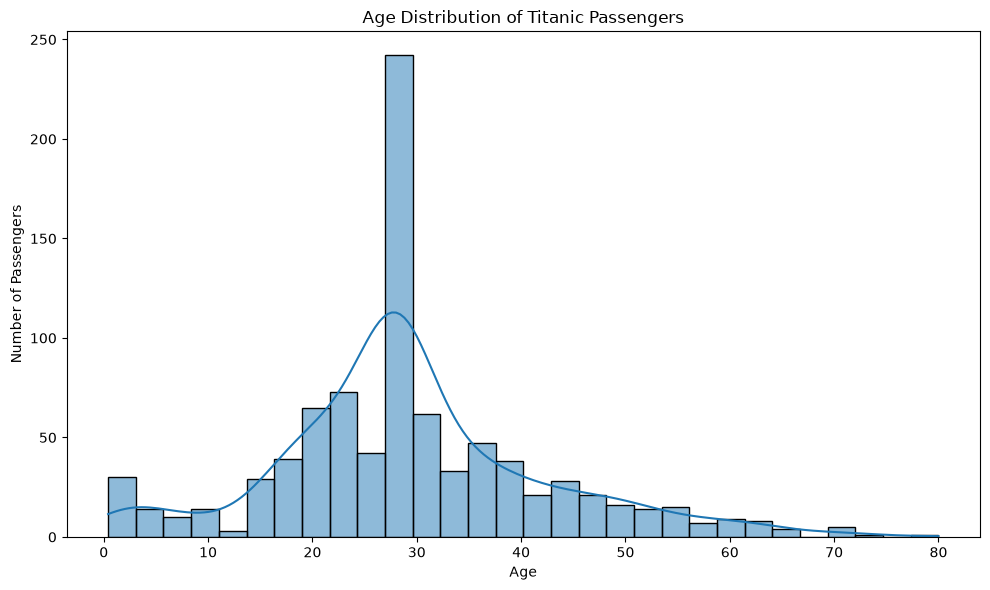

In [30]:
# Age Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
data=df,
x="Age",
bins=30,
kde=True
)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.tight_layout()
plt.show()


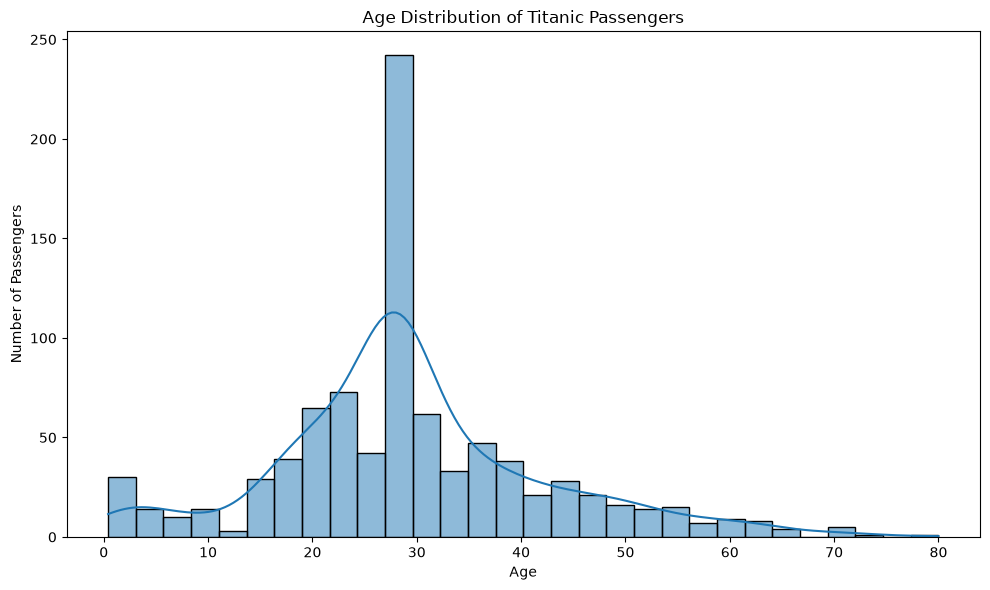

In [31]:
# Save Age Distribution Plot

plt.figure(figsize=(10, 6))

sns.histplot(
data=df,
x="Age",
bins=30,
kde=True
)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.tight_layout()

plt.savefig(
"../images/age_distribution.png",
dpi=300,
bbox_inches="tight"
)

plt.show()


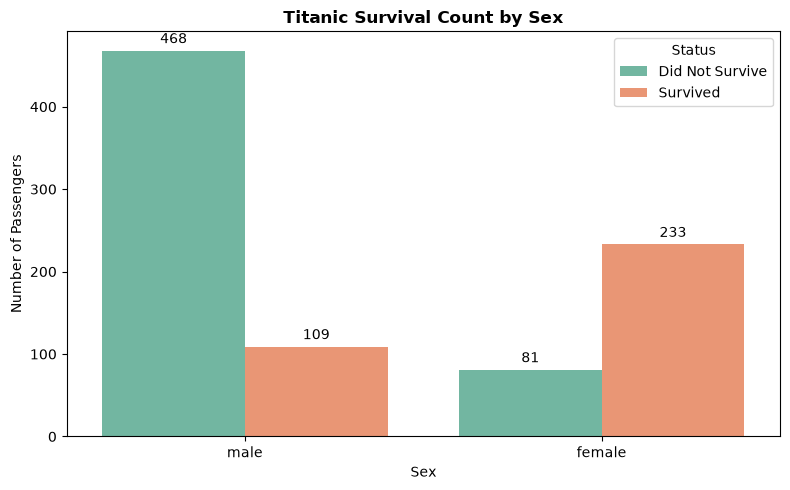

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the grouped bar chart
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Sex', hue='Survived', palette='Set2')

# Add titles and labels
plt.title('Titanic Survival Count by Sex', fontweight='bold')
plt.xlabel('Sex')
plt.ylabel('Number of Passengers')
plt.legend(title='Status', labels=['Did Not Survive', 'Survived'])

# Add numerical labels on top of the bars for clarity
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 3), 
                    textcoords='offset points')

# Save and display
plt.tight_layout()
plt.savefig('../images/survival_by_sex.png', dpi=300)
plt.show()

C:\Users\ARGHYA-LAPTOP\AppData\Local\Temp\ipykernel_8836\716854173.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Survived', palette='viridis')


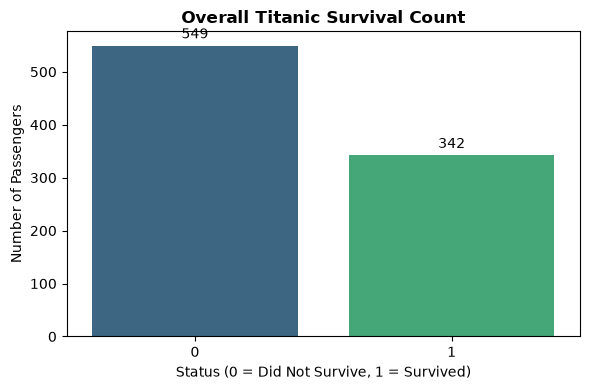

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the basic count plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Survived', palette='viridis')

# Add titles and labels
plt.title('Overall Titanic Survival Count', fontweight='bold')
plt.xlabel('Status (0 = Did Not Survive, 1 = Survived)')
plt.ylabel('Number of Passengers')

# Add numerical labels on top of the bars
for p in ax.patches:
    height = p.get_height()
    if pd.notnull(height) and height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 3), 
                    textcoords='offset points')

# Save and display
plt.tight_layout()
plt.savefig('../images/overall_survival.png', dpi=300)
plt.show()

In [36]:
# Check unique values in categorical columns

print("Sex values:")
print(df["Sex"].unique())

print("\nEmbarked values:")
print(df["Embarked"].unique())


Sex values:
<StringArray>
['male', 'female']
Length: 2, dtype: str

Embarked values:
<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str


# Import LabelEncoder

from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder

label_encoder = LabelEncoder()


In [38]:
# Encode Sex column
# Import LabelEncoder

from sklearn.preprocessing import LabelEncoder

# Create the LabelEncoder object

label_encoder = LabelEncoder()

print("LabelEncoder is ready!")



LabelEncoder is ready!


In [39]:
# Encode Sex column

df["Sex"] = label_encoder.fit_transform(df["Sex"])

print(df["Sex"].head())


0    1
1    0
2    0
3    0
4    1
Name: Sex, dtype: int64


In [41]:
# Check how Sex was encoded

print("Encoding mapping:")

for original, encoded in zip(
label_encoder.classes_,
label_encoder.transform(label_encoder.classes_)
):print(original, "->", encoded)


Encoding mapping:
female -> 0
male -> 1


In [3]:
from sklearn.preprocessing import OneHotEncoder


In [4]:
# Create OneHotEncoder

one_hot_encoder = OneHotEncoder(
sparse_output=False,
handle_unknown="ignore"
)

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


In [7]:
# Load Titanic dataset

df = pd.read_csv("../data/Titanic-Dataset.csv")

print("Dataset loaded successfully!")
print(df.shape)


Dataset loaded successfully!
(891, 12)


In [8]:
# Handle missing Age

df["Age"] = df["Age"].fillna(df["Age"].median())

# Handle missing Embarked

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Remove Cabin

df.drop("Cabin", axis=1, inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [9]:
# Create LabelEncoder

label_encoder = LabelEncoder()

# Create OneHotEncoder

one_hot_encoder = OneHotEncoder(
sparse_output=False,
handle_unknown="ignore"
)

print("Encoders are ready!")


Encoders are ready!


In [10]:
# Encode Sex

df["Sex"] = label_encoder.fit_transform(df["Sex"])

print(df["Sex"].head())


0    1
1    0
2    0
3    0
4    1
Name: Sex, dtype: int64


In [11]:
# One-hot encode Embarked

embarked_encoded = one_hot_encoder.fit_transform(
df[["Embarked"]]
)

print(embarked_encoded)


[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 ...
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]


In [12]:
# Get encoded column names

encoded_column_names = one_hot_encoder.get_feature_names_out(
["Embarked"]
)

print(encoded_column_names)


['Embarked_C' 'Embarked_Q' 'Embarked_S']


In [14]:

# Create a DataFrame from the encoded Embarked values

embarked_df = pd.DataFrame(
    embarked_encoded,
    columns=encoded_column_names,
    index=df.index
)

# Display the encoded data
embarked_df.head()



,Embarked_C,Embarked_Q,Embarked_S
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


In [15]:

# Add the encoded Embarked columns to the original dataset

df = pd.concat([df, embarked_df], axis=1)

# Check the updated dataset
df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,S,0.0,0.0,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C,1.0,0.0,0.0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,S,0.0,0.0,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,S,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,S,0.0,0.0,1.0


In [16]:

# Remove the original categorical Embarked column

df.drop("Embarked", axis=1, inplace=True)

# Check the final columns
print(df.columns)



Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='str')


In [17]:

# Select features for Machine Learning

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked_C",
    "Embarked_Q",
    "Embarked_S"
]

target = "Survived"

# Create X and y
X = df[features]
y = df[target]

# Display the first 5 rows
X.head()



,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,3,1,22.0,1,0,7.2500,0.0,0.0,1.0
1,1,0,38.0,1,0,71.2833,1.0,0.0,0.0
2,3,0,26.0,0,0,7.9250,0.0,0.0,1.0
3,1,0,35.0,1,0,53.1000,0.0,0.0,1.0
4,3,1,35.0,0,0,8.0500,0.0,0.0,1.0


In [18]:

# Select features for Machine Learning

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked_C",
    "Embarked_Q",
    "Embarked_S"
]

target = "Survived"

# Create X and y
X = df[features]
y = df[target]

# Display the first 5 rows
X.head()



,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,3,1,22.0,1,0,7.2500,0.0,0.0,1.0
1,1,0,38.0,1,0,71.2833,1.0,0.0,0.0
2,3,0,26.0,0,0,7.9250,0.0,0.0,1.0
3,1,0,35.0,1,0,53.1000,0.0,0.0,1.0
4,3,1,35.0,0,0,8.0500,0.0,0.0,1.0


In [19]:

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the sizes
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)



Training features: (712, 9)
Testing features: (179, 9)
Training target: (712,)
Testing target: (179,)


In [20]:

# Create the final cleaned dataset

cleaned_df = pd.concat([X, y], axis=1)

# Save the cleaned dataset
cleaned_df.to_csv("../data/Titanic-Cleaned.csv", index=False)

print("Titanic-Cleaned.csv saved successfully! ✅")



Titanic-Cleaned.csv saved successfully! ✅


In [21]:

# Display the first 5 rows
cleaned_df.head()



,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Survived
0,3,1,22.0,1,0,7.2500,0.0,0.0,1.0,0
1,1,0,38.0,1,0,71.2833,1.0,0.0,0.0,1
2,3,0,26.0,0,0,7.9250,0.0,0.0,1.0,1
3,1,0,35.0,1,0,53.1000,0.0,0.0,1.0,1
4,3,1,35.0,0,0,8.0500,0.0,0.0,1.0,0


In [22]:

# Check for missing values

print("Missing values in each column:")
print(cleaned_df.isnull().sum())



Missing values in each column:
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
Survived      0
dtype: int64


In [23]:

# Final information about the cleaned dataset

cleaned_df.info()



<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Pclass      891 non-null    int64  
 1   Sex         891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Embarked_C  891 non-null    float64
 7   Embarked_Q  891 non-null    float64
 8   Embarked_S  891 non-null    float64
 9   Survived    891 non-null    int64  
dtypes: float64(5), int64(5)
memory usage: 69.7 KB
